In [1]:
import pandas as pd
import numpy as np

# Dataset

In [2]:
#!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

In [30]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [31]:
base =["engine_displacement", "horsepower", "vehicle_weight", "model_year","fuel_efficiency_mpg"]

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

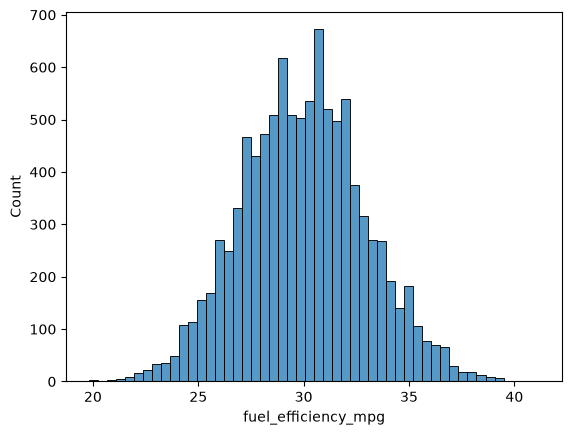

In [33]:
sns.histplot(df.fuel_efficiency_mpg, bins =50)

# Question 1

In [34]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

# Question 2

In [35]:
df.horsepower.mean()

np.float64(254.44601556505535)

In [36]:
df_zero = df.copy()
df_mean = df.copy()

mean_hp = df["horsepower"].mean()

df_zero["horsepower"] = df_zero["horsepower"].fillna(0)

df_mean["horsepower"] = df_mean["horsepower"].fillna(mean_hp)

In [37]:
mean_hp 

np.float64(254.44601556505535)

In [38]:
df_zero["horsepower"].mean()

np.float64(232.1311)

In [39]:
df_mean["horsepower"].mean()

np.float64(254.44601556505532)

In [40]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [41]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [42]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop =True)
df_val = df_val.reset_index(drop =True)
df_test = df_test.reset_index(drop =True)

# Question 3

In [43]:
def train_linear_regression(X,y):
    ones =np.ones(X.shape[0])
    X=np.column_stack([ ones ,X])
    XTX=X.T.dot(X)
    XTX_inv=np.linalg.inv(XTX)
    w= XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]



In [44]:
base= ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
y_train = df_train["fuel_efficiency_mpg"].values
y_val  = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values

In [45]:
del df_train["fuel_efficiency_mpg"]


In [46]:
del df_val["fuel_efficiency_mpg"]

In [47]:
del df_test["fuel_efficiency_mpg"]

In [49]:
def prepare_X_zero(df):
    df.copy()
    df_num =df[base]
    df_num =df_num.fillna(0)
    X=df_num.values
    return X
    
mean_hp = df_train["horsepower"].mean()

def prepare_X_mean(df, mean_hp):
    df_num = df[base].copy()
    df_num = df_num.fillna({"horsepower": mean_hp})
    X = df_num.values
    return X


In [50]:
def rmse(y, y_pred):
    error =y-y_pred
    se =error **2
    mse =se.mean()
    return np.sqrt(mse)

In [51]:
X_train_zero = prepare_X_zero(df_train)
w_0, w_1  = train_linear_regression(X_train_zero, y_train)
X_val_zero = prepare_X_zero(df_val)
y_pred = w_0 +  X_val_zero.dot(w_1)
score=rmse(y_val, y_pred)
round(score , 3)
 

np.float64(2.205)

In [52]:
X_train_mean = prepare_X_mean(df_train, mean_hp)

w_0, w_1 = train_linear_regression(X_train_mean, y_train)
X_val_mean = prepare_X_mean(df_val, mean_hp)

y_pred = w_0 + X_val_mean.dot(w_1)

score_mean = rmse(y_val, y_pred)

round(score_mean, 3)


np.float64(2.202)

# Question 4 

In [53]:
def train_linear_regression_reg(X,y, r =0.001):
    ones =np.ones(X.shape[0])
    X=np.column_stack([ ones ,X])
    
    XTX=X.T.dot(X)
    XTX= XTX + r * np.eye(XTX.shape[0])

    
    XTX_inv=np.linalg.inv(XTX)
    w= XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [54]:
rmsse=[]
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_zero(df_train)
    w0, w1 =train_linear_regression_reg(X_train,y_train, r)
    X_val=prepare_X_zero(df_val)

    y_pred =w0+X_val.dot(w1)

    score= rmse(y_val, y_pred)
    rmsse.append(round(score,4))
    print(r, w0, round(score,4))  

0 -153.88496188223104 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039307081 2.2241
1 -32.331865964969374 2.3492
5 -7.772852209978469 2.4094
10 -3.987116416019025 2.4195
100 -0.4082196488463344 2.4292


# Question 5

In [55]:
rmsse=[]
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    df_train = df_train.reset_index(drop =True)
    df_val = df_val.reset_index(drop =True)
    df_test = df_test.reset_index(drop =True)
    base= ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
    y_train = df_train["fuel_efficiency_mpg"].values
    y_val  = df_val["fuel_efficiency_mpg"].values
    y_test = df_test["fuel_efficiency_mpg"].values
    del df_train["fuel_efficiency_mpg"]
    del df_val["fuel_efficiency_mpg"]
    X_train = prepare_X_zero(df_train)
    w0, w1 =train_linear_regression_reg(X_train,y_train, 0)
    X_val=prepare_X_zero(df_val)

    y_pred =w0+X_val.dot(w1)

    score= rmse(y_val, y_pred)
    rmsse.append(round(score,3))
    print(seed, round(score,3))  


0 2.239
1 2.202
2 2.163
3 2.204
4 2.202
5 2.246
6 2.27
7 2.191
8 2.217
9 2.207


In [56]:
rmsse =np.array(rmsse)
rmsse.mean()
rmsse.std()

np.float64(0.028915220905260306)

# Question 6 

In [57]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
base= ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
y_train = df_train["fuel_efficiency_mpg"].values
y_val  = df_val["fuel_efficiency_mpg"].values
y_test = df_test["fuel_efficiency_mpg"].values
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop =True)
y_full_train=np.concatenate([y_train, y_val])
X_train = prepare_X_zero(df_full_train)
w0, w1 =train_linear_regression_reg(X_train,y_full_train, 0.001)
X_test=prepare_X_zero(df_test)

y_pred =w0+X_test.dot(w1)

score= rmse(y_test, y_pred)
print(round(score,3))  


2.236
